In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter


import warnings; warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

df = pd.read_csv('../datasets/superstore.csv')

In [2]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')
df["postal_code"] = df["postal_code"].astype(str)
df["row_id"] = df["row_id"].astype(str)


In [3]:
df["order_date"] = pd.to_datetime(df["order_date"], format='%m/%d/%Y')
df["ship_date"] = pd.to_datetime(df["ship_date"], format='%m/%d/%Y')
df["order_year"] = df["order_date"].dt.year
df["order_month"] = df["order_date"].dt.to_period("M")
df["order_month_name"] = (df["order_date"].dt.month_name())
df["order_day"] = (df["order_date"].dt.day_name())

In [4]:
df.rename(columns={"sales" : "revenue"}, inplace=True)

In [5]:
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub-category,product_name,revenue,quantity,discount,profit,order_year,order_month,order_month_name,order_day
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,2016-11,November,Tuesday
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,2016-11,November,Tuesday
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,2016-06,June,Sunday
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,2015-10,October,Sunday
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,2015-10,October,Sunday


In [6]:
customer_history = df.groupby("customer_id").agg(
    first_purchase=("order_date", "min"),
    last_purchase=("order_date", "max"),
    total_orders=("order_id", "nunique"),
    total_revenue=("revenue", "sum"),
    total_profit=("profit", "sum"),
    total_quantity=("quantity", "sum")
    ).reset_index()
customer_history

,customer_id,first_purchase,last_purchase,total_orders,total_revenue,total_profit,total_quantity
0,AA-10315,2014-03-31,2017-06-29,5,5563.560,-362.8825,30
1,AA-10375,2014-04-21,2017-12-11,9,1056.390,277.3824,41
2,AA-10480,2014-05-04,2017-04-15,4,1790.512,435.8274,36
3,AA-10645,2014-06-22,2017-11-05,6,5086.935,857.8033,64
4,AB-10015,2014-02-18,2016-11-10,3,886.156,129.3465,13
...,...,...,...,...,...,...,...
788,XP-21865,2014-01-20,2017-11-17,11,2374.658,621.2300,100
789,YC-21895,2014-11-17,2017-12-26,5,5454.350,1305.6290,31
790,YS-21880,2015-01-12,2017-12-21,8,6720.444,1778.2923,58
791,ZC-21910,2014-10-13,2017-11-06,13,8025.707,-1032.1490,105


In [7]:
threshold = 1
array = df['order_id'].value_counts()
keep_ids = array[array > threshold].index
df_unique = df[df['order_id'].isin(keep_ids)]

In [8]:
df_new = df_unique[['customer_id', 'order_date']].sort_values("order_date")
df_new["days_between_orders"] = (df_new.groupby("customer_id")["order_date"].diff().dt.days)

cid = df_new['customer_id'].iloc[0]
df_new[df_new['customer_id'] == cid][['order_date', 'days_between_orders']]

,order_date,days_between_orders
739,2014-01-04,NaN
740,2014-01-04,0.0
741,2014-01-04,0.0
1694,2015-09-25,629.0
1695,2015-09-25,0.0
1696,2015-09-25,0.0
974,2017-10-05,741.0
975,2017-10-05,0.0


In [9]:
purchase_gap = df_new.groupby("customer_id")["days_between_orders"].mean()
purchase_gap.sort_values(ascending=False)

customer_id
SF-20065    382.666667
SL-20155    371.333333
JL-15175    361.333333
AC-10420    345.000000
AR-10405    330.000000
               ...    
VT-21700      0.000000
TC-21145      0.000000
CS-12175      0.000000
CS-11860      0.000000
LD-17005      0.000000
Name: days_between_orders, Length: 769, dtype: float64

In [10]:
snapshot_date = df_unique["order_date"].max() + pd.Timedelta(days=1)
customer_history["recency"] = (snapshot_date - customer_history.last_purchase).dt.days

In [11]:
customer_history["churn_90"] = (customer_history["recency"] > 90).astype(int)

In [12]:
customer_history

,customer_id,first_purchase,last_purchase,total_orders,total_revenue,total_profit,total_quantity,recency,churn_90
0,AA-10315,2014-03-31,2017-06-29,5,5563.560,-362.8825,30,185,1
1,AA-10375,2014-04-21,2017-12-11,9,1056.390,277.3824,41,20,0
2,AA-10480,2014-05-04,2017-04-15,4,1790.512,435.8274,36,260,1
3,AA-10645,2014-06-22,2017-11-05,6,5086.935,857.8033,64,56,0
4,AB-10015,2014-02-18,2016-11-10,3,886.156,129.3465,13,416,1
...,...,...,...,...,...,...,...,...,...
788,XP-21865,2014-01-20,2017-11-17,11,2374.658,621.2300,100,44,0
789,YC-21895,2014-11-17,2017-12-26,5,5454.350,1305.6290,31,5,0
790,YS-21880,2015-01-12,2017-12-21,8,6720.444,1778.2923,58,10,0
791,ZC-21910,2014-10-13,2017-11-06,13,8025.707,-1032.1490,105,55,0


In [13]:
df_new

,customer_id,order_date,days_between_orders
739,PO-19195,2014-01-04,NaN
740,PO-19195,2014-01-04,0.0
741,PO-19195,2014-01-04,0.0
7480,ME-17320,2014-01-06,NaN
7479,ME-17320,2014-01-06,0.0
...,...,...,...
1297,EB-13975,2017-12-30,446.0
1296,EB-13975,2017-12-30,0.0
908,PO-18865,2017-12-30,147.0
907,PO-18865,2017-12-30,0.0


In [14]:
df_unique = df_unique.merge(df_new[["customer_id", "days_between_orders"]], on="customer_id")

In [15]:
customer_stats = (df_unique.sort_values(["order_date"]).groupby("customer_id")
    .agg(
        avg_gap=("days_between_orders","mean"),
        std_gap=("days_between_orders","std"),
        frequency=("order_id","nunique")
    )
)
customer_stats

,avg_gap,std_gap,frequency
customer_id,,,
AA-10315,131.777778,209.721473,4
AA-10375,115.777778,211.759232,4
AA-10480,4.444444,12.641212,2
AA-10645,50.312500,101.949384,5
AB-10015,244.750000,434.932163,2
...,...,...,...
XP-21865,66.380952,170.193388,5
YC-21895,164.750000,292.768433,2
YS-21880,125.833333,228.812941,3


In [16]:
customer_stats["churn_threshold"] = (customer_stats["avg_gap"] + customer_stats["std_gap"])
customer_stats

,avg_gap,std_gap,frequency,churn_threshold
customer_id,,,,
AA-10315,131.777778,209.721473,4,341.499251
AA-10375,115.777778,211.759232,4,327.537010
AA-10480,4.444444,12.641212,2,17.085657
AA-10645,50.312500,101.949384,5,152.261884
AB-10015,244.750000,434.932163,2,679.682163
...,...,...,...,...
XP-21865,66.380952,170.193388,5,236.574341
YC-21895,164.750000,292.768433,2,457.518433
YS-21880,125.833333,228.812941,3,354.646274


In [17]:
customer_history = customer_history.merge(customer_stats.churn_threshold, on="customer_id")
customer_history

,customer_id,first_purchase,last_purchase,total_orders,total_revenue,total_profit,total_quantity,recency,churn_90,churn_threshold
0,AA-10315,2014-03-31,2017-06-29,5,5563.560,-362.8825,30,185,1,341.499251
1,AA-10375,2014-04-21,2017-12-11,9,1056.390,277.3824,41,20,0,327.537010
2,AA-10480,2014-05-04,2017-04-15,4,1790.512,435.8274,36,260,1,17.085657
3,AA-10645,2014-06-22,2017-11-05,6,5086.935,857.8033,64,56,0,152.261884
4,AB-10015,2014-02-18,2016-11-10,3,886.156,129.3465,13,416,1,679.682163
...,...,...,...,...,...,...,...,...,...,...
764,XP-21865,2014-01-20,2017-11-17,11,2374.658,621.2300,100,44,0,236.574341
765,YC-21895,2014-11-17,2017-12-26,5,5454.350,1305.6290,31,5,0,457.518433
766,YS-21880,2015-01-12,2017-12-21,8,6720.444,1778.2923,58,10,0,354.646274
767,ZC-21910,2014-10-13,2017-11-06,13,8025.707,-1032.1490,105,55,0,136.653106


In [18]:
customer_history["churn"] = customer_history["recency"] > customer_history["churn_threshold"]

In [19]:
print(np.sum(customer_history["churn_90"] == 1))
print(np.sum(customer_history["churn"] == 1))

343
240


In [20]:
customer_survival = (df.groupby("customer_id").agg(
    first_purchase=("order_date","min"),
    last_purchase=("order_date","max"),
    monetary=("revenue","mean"),
    frequency=("order_id","nunique"),
    total_profit=("profit","sum")
).reset_index())
customer_survival["duration"] = (customer_survival["last_purchase"] - customer_survival["first_purchase"]).dt.days
customer_survival

,customer_id,first_purchase,last_purchase,monetary,frequency,total_profit,duration
0,AA-10315,2014-03-31,2017-06-29,505.778182,5,-362.8825,1186
1,AA-10375,2014-04-21,2017-12-11,70.426000,9,277.3824,1330
2,AA-10480,2014-05-04,2017-04-15,149.209333,4,435.8274,1077
3,AA-10645,2014-06-22,2017-11-05,282.607500,6,857.8033,1232
4,AB-10015,2014-02-18,2016-11-10,147.692667,3,129.3465,996
...,...,...,...,...,...,...,...
788,XP-21865,2014-01-20,2017-11-17,84.809214,11,621.2300,1397
789,YC-21895,2014-11-17,2017-12-26,681.793750,5,1305.6290,1135
790,YS-21880,2015-01-12,2017-12-21,560.037000,8,1778.2923,1074
791,ZC-21910,2014-10-13,2017-11-06,258.893774,13,-1032.1490,1120


In [21]:
cutoff_date = pd.Timestamp("2017-06-30")
future_customers = (df[df["order_date"] > cutoff_date]["customer_id"].unique())
future_customers

array(['SF-20065', 'MA-17560', 'LC-16930', 'ES-14080', 'TB-21520',
       'KB-16600', 'CS-12400', 'PG-18895', 'RB-19705', 'PN-18775',
       'JM-15250', 'CV-12805', 'TS-21610', 'SH-19975', 'SG-20080',
       'VM-21685', 'FH-14365', 'LC-17140', 'LE-16810', 'JH-15985',
       'DB-13120', 'CC-12670', 'CA-12310', 'KH-16690', 'BB-10990',
       'AG-10495', 'JH-15910', 'DJ-13510', 'TD-20995', 'KW-16435',
       'AR-10405', 'MV-18190', 'SS-20140', 'RF-19840', 'KH-16510',
       'KC-16675', 'VB-21745', 'MP-17965', 'NF-18385', 'JM-15265',
       'KH-16630', 'BB-11545', 'EB-13705', 'LS-17245', 'BN-11515',
       'PH-18790', 'JC-15340', 'EP-13915', 'AS-10135', 'RC-19960',
       'GT-14710', 'LP-17080', 'FP-14320', 'EB-13840', 'JF-15415',
       'CS-11950', 'DV-13465', 'CK-12595', 'NG-18355', 'MO-17800',
       'BD-11605', 'JL-15835', 'TW-21025', 'CC-12430', 'RB-19570',
       'GT-14635', 'RA-19285', 'Dl-13600', 'AP-10915', 'KC-16540',
       'JF-15355', 'RF-19735', 'CP-12340', 'BF-11020', 'JC-161

In [22]:
customer_survival["event"] = (~customer_survival["customer_id"].isin(future_customers)).astype(int)
print(customer_survival[customer_survival["event"] == 1].shape[0])

199


In [23]:
customer_survival = customer_survival.query("frequency > 3")

In [24]:
kmf = KaplanMeierFitter()
kmf.fit(durations=customer_survival["duration"], event_observed=customer_survival["event"])

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 694 total observations, 550 right-censored observations>

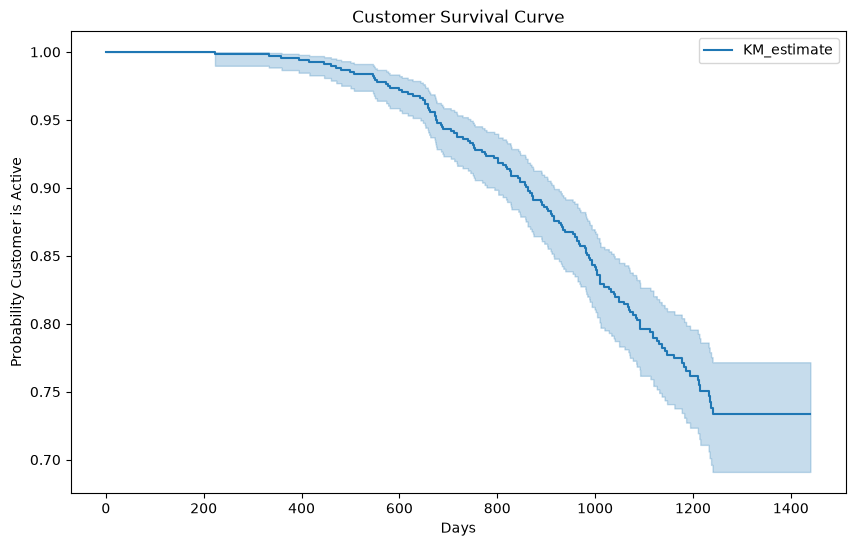

In [25]:
plt.figure(figsize=(10,6))
kmf.plot_survival_function()
plt.title("Customer Survival Curve")
plt.xlabel("Days")
plt.ylabel("Probability Customer is Active")
plt.show()

In [26]:
customer_survival["duration"] = np.where(customer_survival["event"] == 1,
    (customer_survival["last_purchase"] -  customer_survival["first_purchase"]).dt.days, (cutoff_date -customer_survival["first_purchase"]).dt.days)

In [27]:
customer_survival["frequency"].value_counts()

frequency
5     134
7     116
6     107
4      96
8      82
9      71
10     39
11     23
12     18
13      7
17      1
Name: count, dtype: int64

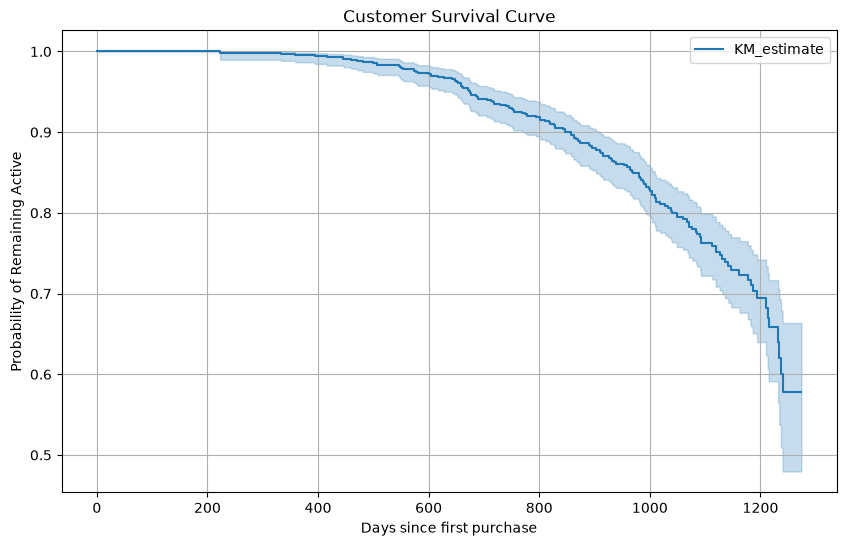

In [28]:
kmf = KaplanMeierFitter()
kmf.fit(durations=customer_survival["duration"], event_observed=customer_survival["event"])

plt.figure(figsize=(10,6))
kmf.plot_survival_function()
plt.title("Customer Survival Curve")
plt.xlabel("Days since first purchase")
plt.ylabel("Probability of Remaining Active")
plt.grid()
plt.show()